In [1]:
#installing dependencies
!pip install mediapipe opencv-python tensorflow matplotlib numpy scikit-learn seaborn
!pip install ffmpeg-python

  Using cached mediapipe-0.10.21-cp312-cp312-win_amd64.whl.metadata (10 kB)
  Using cached tensorflow-2.20.0-cp312-cp312-win_amd64.whl.metadata (4.6 kB)
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
  Using cached tensorflow-2.19.1-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
Using cached mediapipe-0.10.21-cp312-cp312-win_amd64.whl (51.0 MB)
Using cached tensorflow-2.19.1-cp312-cp312-win_amd64.whl (376.0 MB)
   ---------------------------------------- 0.0/491.3 kB ? eta -:--:--
   --- ------------------------------------ 41.0/491.3 kB ? eta -:--:--
   ----------- ---------------------------- 143.4/491.3 kB 1.4 MB/s eta 0:00:01
   ---------------------- ----------------- 276.5/491.3 kB 1.7 MB/s eta 0:00:01
   --------------------------- ------------ 337.9/491.3 kB 1.6 MB/s eta 0:00:01
   ------------------------------------ --- 450.6/491.3 kB 1.7 MB/s eta 0:00:01
   ----------------------

In [3]:
!pip uninstall -y mediapipe

Found existing installation: mediapipe 0.10.21
Uninstalling mediapipe-0.10.21:
  Successfully uninstalled mediapipe-0.10.21


In [4]:
!pip install mediapipe==0.10.14 --no-cache-dir

   ---------------------------------------- 0.0/50.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/50.8 MB 653.6 kB/s eta 0:01:18
   ---------------------------------------- 0.1/50.8 MB 1.2 MB/s eta 0:00:42
   ---------------------------------------- 0.2/50.8 MB 1.4 MB/s eta 0:00:36
   ---------------------------------------- 0.3/50.8 MB 1.8 MB/s eta 0:00:28
   ---------------------------------------- 0.6/50.8 MB 2.3 MB/s eta 0:00:22
    --------------------------------------- 0.8/50.8 MB 2.8 MB/s eta 0:00:18
    --------------------------------------- 1.0/50.8 MB 3.3 MB/s eta 0:00:16
    --------------------------------------- 1.0/50.8 MB 3.3 MB/s eta 0:00:16
    --------------------------------------- 1.0/50.8 MB 3.3 MB/s eta 0:00:16
    --------------------------------------- 1.0/50.8 MB 3.3 MB/s eta 0:00:16
   - -------------------------------------- 1.5/50.8 MB 2.8 MB/s eta 0:00:18
   - -------------------------------------- 1.7/50.8 MB 3.1 MB/s eta 0:00:16
   -

In [2]:
!pip uninstall -y tensorflow

Found existing installation: tensorflow 2.19.1
Uninstalling tensorflow-2.19.1:
  Successfully uninstalled tensorflow-2.19.1


In [3]:
!pip install tensorflow==2.17.0 --no-cache-dir

   ---------------------------------------- 0.0/385.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/385.2 MB 1.3 MB/s eta 0:04:52
   ---------------------------------------- 0.1/385.2 MB 1.8 MB/s eta 0:03:36
   ---------------------------------------- 0.3/385.2 MB 2.2 MB/s eta 0:02:53
   ---------------------------------------- 0.4/385.2 MB 2.3 MB/s eta 0:02:48
   ---------------------------------------- 0.6/385.2 MB 2.8 MB/s eta 0:02:18
   ---------------------------------------- 0.9/385.2 MB 3.3 MB/s eta 0:01:57
   ---------------------------------------- 1.0/385.2 MB 3.7 MB/s eta 0:01:45
   ---------------------------------------- 1.0/385.2 MB 3.7 MB/s eta 0:01:45
   ---------------------------------------- 1.0/385.2 MB 3.7 MB/s eta 0:01:45
   ---------------------------------------- 1.4/385.2 MB 3.0 MB/s eta 0:02:10
   ---------------------------------------- 1.7/385.2 MB 3.5 MB/s eta 0:01:51
   ---------------------------------------- 1.8/385.2 MB 3.2 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.1 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
jaxlib 0.7.1 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.


   ------------ ------------------------- 123.1/385.2 MB 524.2 kB/s eta 0:08:20
   ------------ ------------------------- 123.2/385.2 MB 522.9 kB/s eta 0:08:21
   ------------ ------------------------- 123.2/385.2 MB 522.5 kB/s eta 0:08:22
   ------------ ------------------------- 123.3/385.2 MB 522.1 kB/s eta 0:08:22
   ------------ ------------------------- 123.3/385.2 MB 521.3 kB/s eta 0:08:23
   ------------ ------------------------- 123.4/385.2 MB 520.4 kB/s eta 0:08:23
   ------------ ------------------------- 123.4/385.2 MB 520.0 kB/s eta 0:08:24
   ------------ ------------------------- 123.5/385.2 MB 519.2 kB/s eta 0:08:25
   ------------ ------------------------- 123.5/385.2 MB 518.4 kB/s eta 0:08:25
   ------------ ------------------------- 123.6/385.2 MB 518.0 kB/s eta 0:08:26
   ------------ ------------------------- 123.6/385.2 MB 517.1 kB/s eta 0:08:26
   ------------ ------------------------- 123.7/385.2 MB 516.3 kB/s eta 0:08:27
   ------------ ------------------------

In [4]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
from collections import deque
import pandas as pd

In [33]:
# Initialize MediaPipe Pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    enable_segmentation=False,
    smooth_segmentation=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [34]:
from pose_utils import extract_pose_sequences, calculate_biomechanical_features, prepare_dataset
from model_definition import create_acl_risk_model

In [1]:
import re

In [2]:
# Build dataset 
def build_acl_dataset(base_dir="acl_data"):
    """
    Scans a directory for ACL videos and extracts:
    - Participant ID 
    - View (front/side)
    - Label (low/high)
    Returns:
      - df: DataFrame with metadata
      - video_dataset: {video_path: label}
    """
    
    data_records = []
    for file in sorted(os.listdir(base_dir)):
        if file.endswith(".mp4"):
            match = re.match(r"(P\d+)_([a-zA-Z]+)_([a-zA-Z]+)\.mp4", file)
            if match:
                pid, view, label = match.groups()
                path = os.path.join(base_dir, file)
                data_records.append({
                    "path": path,
                    "participant": pid,
                    "view": view.lower(),
                    "label": label.lower()
                })
            else:
                print(f"Skipped invalid file name: {file}")

    df = pd.DataFrame(data_records)
    video_dataset = {row["path"]: row["label"] for _, row in df.iterrows()}

    print(f"Found {len(df)} videos from {df['participant'].nunique()} participants.")
    print(df.groupby(['view', 'label']).size().unstack(fill_value=0))
    return df, video_dataset


In [6]:
df, video_dataset = build_acl_dataset("acl_data")
label_mapping = {"low": 0, "high": 1}

Found 20 videos from 10 participants.
label  high  low
view            
front     5    5
side      5    5


In [7]:
# Prepare dataset 
X, y = prepare_dataset(video_dataset, label_mapping, sequence_length=30)

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Processing acl_data\P01_front_high.mp4...


C:\Users\ADMIN\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing acl_data\P01_side_high.mp4...
Processing acl_data\P02_front_low.mp4...
Processing acl_data\P02_side_low.mp4...
Processing acl_data\P03_front_high.mp4...
Processing acl_data\P03_side_high.mp4...
Processing acl_data\P04_front_low.mp4...
Processing acl_data\P04_side_low.mp4...
Processing acl_data\P05_front_high.mp4...
Processing acl_data\P05_side_high.mp4...
Processing acl_data\P06_front_low.mp4...
Processing acl_data\P06_side_low.mp4...
Processing acl_data\P07_front_low.mp4...
Processing acl_data\P07_side_low.mp4...
Processing acl_data\P08_front_high.mp4...
Processing acl_data\P08_side_high.mp4...
Processing acl_data\P09_front_low.mp4...
Processing acl_data\P09_side_low.mp4...
Processing acl_data\P10_front_high.mp4...
Processing acl_data\P10_side_high.mp4...
Dataset shape: (2437, 30, 3)
Labels shape: (2437,)


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [11]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1705, 30, 3) (1705,)
Validation: (366, 30, 3) (366,)
Test: (366, 30, 3) (366,)


In [12]:
# Create and compile the model 
model = create_acl_risk_model(
    sequence_length=X.shape[1],
    num_features=X.shape[2]
)
model.summary()

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 30, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 30, 32)              │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 30, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,450 (134.57 KB)

 Trainable params: 34,258 (133.82 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
# Train the model 
callbacks = [
    EarlyStopping(
        monitor='val_loss',       # Watch validation loss
        patience=10,              # Stop if it doesn’t improve for 10 epochs
        restore_best_weights=True # Revert to best model
    ),
    ReduceLROnPlateau(
        monitor='val_loss',       # Reduce learning rate when val loss stalls
        patience=5, 
        factor=0.5, 
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.6909 - loss: 0.5800 - val_accuracy: 0.6585 - val_loss: 0.5898 - learning_rate: 0.0010
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7672 - loss: 0.4648 - val_accuracy: 0.7842 - val_loss: 0.4147 - learning_rate: 0.0010
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7818 - loss: 0.4207 - val_accuracy: 0.8033 - val_loss: 0.3941 - learning_rate: 0.0010
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7959 - loss: 0.3965 - val_accuracy: 0.7842 - val_loss: 0.4083 - learning_rate: 0.0010
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8059 - loss: 0.3803 - val_accuracy: 0.8197 - val_loss: 0.4064 - learning_rate: 0.0010
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8170 - loss: 0.3654 - val_accuracy: 0.8033 - val_loss: 0.2986 - learning_rate: 0.0010
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8135 - 

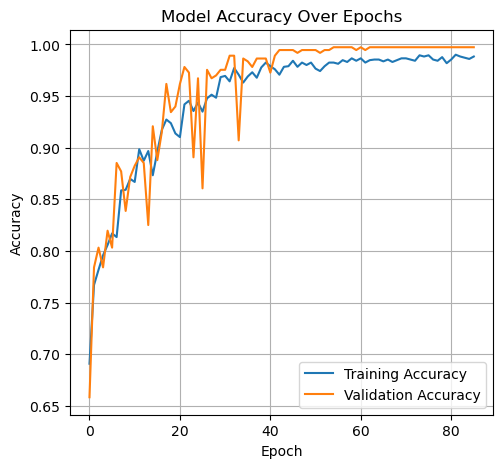

In [15]:
# Plot training history
plt.figure(figsize=(12, 5))

# Accuracy plot 
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True);

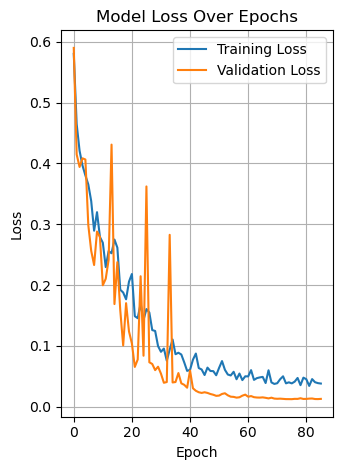

In [16]:
#Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True);

plt.tight_layout()
plt.show()

In [27]:
model.save("model/acl_risk_model.h5")

In [17]:
# Predict class probabilities
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step


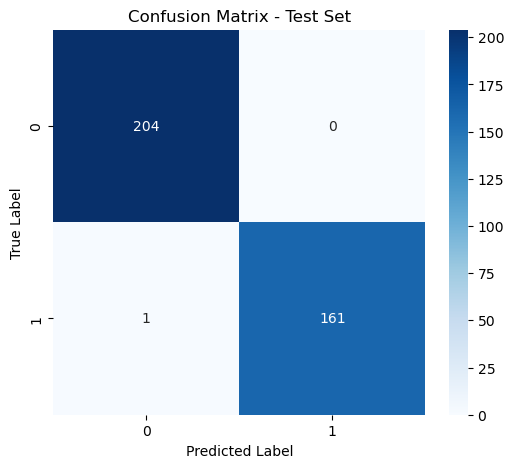

In [20]:
#test set reports
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show();

In [21]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, 
                          target_names=['Low Risk', 'High Risk']))


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       204
   High Risk       1.00      0.99      1.00       162

    accuracy                           1.00       366
   macro avg       1.00      1.00      1.00       366
weighted avg       1.00      1.00      1.00       366




Feature Importance Analysis (approximate):
Knee Valgus: 0.3159
Knee Flexion: 0.3654
Trunk Lean: 0.3187


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23356\1712014416.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_names, palette='viridis')


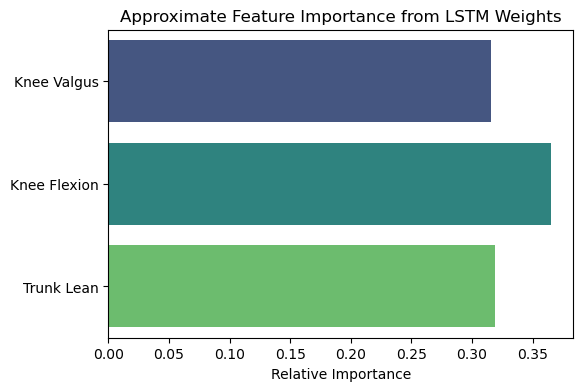

In [24]:
#Feature importance analysis (approximation)
print("\nFeature Importance Analysis (approximate):")

feature_names = ['Knee Valgus', 'Knee Flexion', 'Trunk Lean']

# Get the input kernel weights from the first LSTM layer
lstm_weights = model.layers[0].get_weights()[0]  # shape: (num_features, 4 * units)

# Compute average absolute weight per feature
feature_importance = np.mean(np.abs(lstm_weights), axis=1)

# Normalize to sum to 1 (for interpretability)
feature_importance = feature_importance / np.sum(feature_importance)

# Display results
for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

# Optional: visualize
plt.figure(figsize=(6, 4))
sns.barplot(x=feature_importance, y=feature_names, palette='viridis')
plt.title('Approximate Feature Importance from LSTM Weights')
plt.xlabel('Relative Importance')
plt.show();

In [1]:
import sys
sys.path.append("Biomechanics")  

from tensorflow.keras.models import load_model
from video_overlay_analysis import analyze_video_with_overlay

# Load your trained model
model = load_model("model/acl_risk_model.h5")

# Run the analysis
output_path = analyze_video_with_overlay("acl_data/P02_front_low.mp4", model)

C:\Users\ADMIN\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Analysis complete. Output saved to: output/output_video.mp4
